In [24]:
import pandas as pd

# 读取 parquet
df_train = pd.read_parquet("df_trainsub_full_rl.parquet")
df_test  = pd.read_parquet("df_testsub_full_rl.parquet")

# 合并成一个 frame
df_full = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# 排序（非常重要，RL / lag 都需要）
df_full = df_full.sort_values(
    ["SecuCode", "TradingDay", "TimeEnd"]
).reset_index(drop=True)

print("df_full shape:", df_full.shape)

df_full.head()

df_full shape: (1538980, 30)


,SecuCode,TradingDay,TimeStart,TimeEnd,mid,spread,microprice_minus_mid,Volume_sum,Turnover_sum,DealNum_sum,...,spread_over_mid,microprice_minus_mid_over_mid,log_volume_sum,log_volume_sum_cs_rank,ret_mid_t1_lag1,ret_mid_t1_lag2,signal_pre_boost,signal_pre_boost_cs_z,sig_mean_5,sig_std_5
0,400,20180105,1400,1415,12.545907,0.009359,-0.001625,666449.0,8929837.0,246.0,...,0.000746,-0.000130,13.409720,0.510638,0.000747,-0.002235,-0.000184,-0.000433,0.136814,0.301263
1,400,20180105,1415,1430,12.545907,0.009359,0.004534,649400.0,8709588.0,249.0,...,0.000746,0.000361,13.383806,0.446809,0.000000,0.000747,0.000286,0.876286,0.875732,0.133308
2,400,20180105,1430,1445,12.573985,0.009359,0.001348,766000.0,10288242.0,369.0,...,0.000744,0.000107,13.548939,0.382979,0.002238,0.000000,-0.000036,-0.033422,0.208418,0.347763
3,400,20180105,1445,1500,12.545907,0.009359,-0.003165,686098.0,9200730.0,274.0,...,0.000746,-0.000252,13.438777,0.404255,-0.002233,0.002238,-0.000376,-0.933310,-0.391072,0.697177
4,400,20180108,930,945,12.508471,0.009359,0.003633,858900.0,11482996.0,493.0,...,0.000748,0.000290,13.663409,0.234043,-0.002984,-0.002233,-0.000187,-0.530542,0.539987,0.624971


In [25]:
df_train.columns

Index(['SecuCode', 'TradingDay', 'TimeStart', 'TimeEnd', 'mid', 'spread',
       'microprice_minus_mid', 'Volume_sum', 'Turnover_sum', 'DealNum_sum',
       'VWAP', 'ret_mid_t1', 'signal_hybrid', 'signal_ssm_tf',
       'signal_tf_cross', 'signal_gat_tf', 'signal_hybrid_cs_z',
       'signal_ssm_tf_cs_z', 'signal_tf_cross_cs_z', 'signal_gat_tf_cs_z',
       'spread_over_mid', 'microprice_minus_mid_over_mid', 'log_volume_sum',
       'log_volume_sum_cs_rank', 'ret_mid_t1_lag1', 'ret_mid_t1_lag2',
       'signal_pre_boost', 'signal_pre_boost_cs_z', 'sig_mean_5', 'sig_std_5'],
      dtype='object')

In [27]:
import numpy as np
import pandas as pd


# =========================================================
# 1) 直接用当前内存里的 df_train / df_test
# =========================================================
print("train shape:", df_train.shape)
print("test  shape:", df_test.shape)


# =========================================================
# 2) 先打标记，再合并成一个 frame
# =========================================================
df_train_ = df_train.copy()
df_test_  = df_test.copy()

df_train_["dataset_split"] = "train"
df_test_["dataset_split"]  = "test"

df_full = pd.concat([df_train_, df_test_], axis=0, ignore_index=True)

print("merged df_full shape:", df_full.shape)


# =========================================================
# 3) 排序（非常重要）
# =========================================================
sort_cols = ["SecuCode", "TradingDay", "TimeEnd"]
df_full = df_full.sort_values(sort_cols).reset_index(drop=True)


# =========================================================
# 4) 只保留有意义的列
# =========================================================
keep_cols = [
    "dataset_split",
    "SecuCode",
    "TradingDay",
    "TimeEnd",
    "mid",
    "spread",
    "ret_mid_t1",

    # agent signals
    "signal_pre_boost_cs_z",
    "signal_hybrid_cs_z",
    "signal_ssm_tf_cs_z",
    "signal_tf_cross_cs_z",
    "signal_gat_tf_cs_z",

    # shared state
    "spread_over_mid",
    "microprice_minus_mid_over_mid",
    "log_volume_sum",
    "log_volume_sum_cs_rank",
    "ret_mid_t1_lag1",
    "ret_mid_t1_lag2",

    # summary
    "sig_mean_5",
    "sig_std_5",
]

keep_cols = [c for c in keep_cols if c in df_full.columns]
df_full = df_full[keep_cols].copy()

print("after keep useful cols:", df_full.shape)
print(df_full.columns.tolist())


# =========================================================
# 5) 统一处理 inf / nan
# =========================================================
df_full = df_full.replace([np.inf, -np.inf], np.nan)

if "spread" in df_full.columns:
    df_full["spread"] = df_full["spread"].fillna(0.0).clip(lower=0.0)

if "mid" in df_full.columns:
    df_full["mid"] = df_full["mid"].replace(0, np.nan)
    df_full["mid"] = df_full.groupby("SecuCode", sort=False)["mid"].ffill()
    df_full["mid"] = df_full.groupby("SecuCode", sort=False)["mid"].bfill()
    df_full["mid"] = df_full["mid"].fillna(1.0)

num_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
fill_zero_cols = [c for c in num_cols if c != "mid"]
df_full[fill_zero_cols] = df_full[fill_zero_cols].fillna(0.0)


# =========================================================
# 6) 再排序一次
# =========================================================
df_full = df_full.sort_values(["SecuCode", "TradingDay", "TimeEnd"]).reset_index(drop=True)


# =========================================================
# 7) 检查缺失
# =========================================================
na_cnt = df_full.isna().sum()
na_cnt = na_cnt[na_cnt > 0]

print("\nremaining NA columns:")
print(na_cnt if len(na_cnt) > 0 else "No remaining NA.")


# =========================================================
# 8) 保存
# =========================================================
df_full.to_parquet("df_full_rl_clean.parquet", index=False)

print("\nSaved to df_full_rl_clean.parquet")
print("final shape:", df_full.shape)

df_full.head()

train shape: (1136222, 30)
test  shape: (402758, 30)
merged df_full shape: (1538980, 31)
after keep useful cols: (1538980, 20)
['dataset_split', 'SecuCode', 'TradingDay', 'TimeEnd', 'mid', 'spread', 'ret_mid_t1', 'signal_pre_boost_cs_z', 'signal_hybrid_cs_z', 'signal_ssm_tf_cs_z', 'signal_tf_cross_cs_z', 'signal_gat_tf_cs_z', 'spread_over_mid', 'microprice_minus_mid_over_mid', 'log_volume_sum', 'log_volume_sum_cs_rank', 'ret_mid_t1_lag1', 'ret_mid_t1_lag2', 'sig_mean_5', 'sig_std_5']

remaining NA columns:
No remaining NA.

Saved to df_full_rl_clean.parquet
final shape: (1538980, 20)


,dataset_split,SecuCode,TradingDay,TimeEnd,mid,spread,ret_mid_t1,signal_pre_boost_cs_z,signal_hybrid_cs_z,signal_ssm_tf_cs_z,signal_tf_cross_cs_z,signal_gat_tf_cs_z,spread_over_mid,microprice_minus_mid_over_mid,log_volume_sum,log_volume_sum_cs_rank,ret_mid_t1_lag1,ret_mid_t1_lag2,sig_mean_5,sig_std_5
0,train,400,20180105,1415,12.545907,0.009359,0.000000,-0.000433,0.380603,-0.289993,0.136761,0.457133,0.000746,-0.000130,13.409720,0.510638,0.000747,-0.002235,0.136814,0.301263
1,train,400,20180105,1430,12.545907,0.009359,0.002238,0.876286,0.860622,1.090896,0.822537,0.728321,0.000746,0.000361,13.383806,0.446809,0.000000,0.000747,0.875732,0.133308
2,train,400,20180105,1445,12.573985,0.009359,-0.002233,-0.033422,0.567285,0.081809,-0.161230,0.587649,0.000744,0.000107,13.548939,0.382979,0.002238,0.000000,0.208418,0.347763
3,train,400,20180105,1500,12.545907,0.009359,-0.002984,-0.933310,0.180152,-0.915851,-0.823471,0.537120,0.000746,-0.000252,13.438777,0.404255,-0.002233,0.002238,-0.391072,0.697177
4,train,400,20180108,945,12.508471,0.009359,0.001871,-0.530542,0.746215,0.789122,1.095069,0.600072,0.000748,0.000290,13.663409,0.234043,-0.002984,-0.002233,0.539987,0.624971


In [34]:
# =========================================================
# Multi-Agent TD3-style Shared Critic + A-share T+1 execution
# One unified frame version
#
# Fixed / improved:
# 1) universe mismatch bug fixed by code-aligned portfolio remap
# 2) TD3 twin critics
# 3) delayed actor update
# 4) gate regularization
# 5) raw/scaled reward history
# 6) topk support
# 7) one unified frame with dataset_split
# 8) supports continuous train->test rolling state
# =========================================================

import os
import copy
import json
import random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

torch.set_float32_matmul_precision("high")


# =========================================================
# 0) Seed / Device
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# =========================================================
# 1) Config
# =========================================================
@dataclass
class CFG:
    # ---------- basic columns ----------
    stock_col: str = "SecuCode"
    day_col: str = "TradingDay"
    time_col: str = "TimeEnd"
    price_col: str = "mid"
    spread_col: str = "spread"
    ret_col: str = "ret_mid_t1"
    split_col: str = "dataset_split"

    # ---------- agents ----------
    agent_signal_cols = (
        "signal_pre_boost_cs_z",
        "signal_hybrid_cs_z",
        "signal_ssm_tf_cs_z",
        "signal_tf_cross_cs_z",
        "signal_gat_tf_cs_z",
    )

    # ---------- shared state features ----------
    shared_state_cols = (
        "sig_mean_5",
        "sig_std_5",
        "spread_over_mid",
        "microprice_minus_mid_over_mid",
        "log_volume_sum_cs_rank",
        "ret_mid_t1_lag1",
        "ret_mid_t1_lag2",
    )

    # ---------- fee / cost ----------
    broker_commission_rate: float = 0.0
    exchange_reg_transfer_rate: float = 0.0
    sell_stamp_duty_rate: float = 0.0
    use_half_spread: bool = True

    # ---------- portfolio ----------
    long_only: bool = True
    topk: int | None = 20
    max_weight_per_stock: float = 0.20

    # ---------- reward ----------
    risk_penalty_lambda: float = 0.0
    turnover_penalty_lambda: float = 0.0
    reward_scale: float = 1000.0

    # ---------- RL ----------
    hidden_dim: int = 128
    actor_lr: float = 1e-4
    critic_lr: float = 3e-4
    gamma: float = 0.95
    tau: float = 0.005

    replay_capacity: int = 300000
    batch_size: int = 512
    warmup_steps: int = 2000
    epochs: int = 15

    action_noise_std: float = 0.05         # pre-squash noise std
    target_policy_noise_std: float = 0.02  # TD3 target smoothing
    target_policy_noise_clip: float = 0.05

    train_every: int = 2
    updates_per_step: int = 2
    policy_delay: int = 2

    gate_reg_lambda: float = 0.01

    # ---------- richer state ----------
    topk_state_k: int = 5

    # ---------- save ----------
    save_dir: str = "matd3_sharedcritic_models_richer_state"


cfg = CFG()

agent_cols = list(cfg.agent_signal_cols)
shared_cols = list(cfg.shared_state_cols)
n_agents = len(agent_cols)
action_dim = 1


# =========================================================
# 2) Helpers
# =========================================================
def _safe_std(x):
    x = np.asarray(x, dtype=np.float32)
    return float(np.std(x)) if len(x) else 0.0

def _safe_mean(x):
    x = np.asarray(x, dtype=np.float32)
    return float(np.mean(x)) if len(x) else 0.0

def _safe_quantile(x, q):
    x = np.asarray(x, dtype=np.float32)
    return float(np.quantile(x, q)) if len(x) else 0.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return 0.0
    mu = x.mean()
    sd = x.std()
    if sd < 1e-12:
        return 0.0
    z = (x - mu) / sd
    return float((z ** 3).mean())

def _safe_kurtosis_excess(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 4:
        return 0.0
    mu = x.mean()
    sd = x.std()
    if sd < 1e-12:
        return 0.0
    z = (x - mu) / sd
    return float((z ** 4).mean() - 3.0)

def _safe_corr(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    if len(x) == 0 or len(y) == 0:
        return 0.0
    xs = x.std()
    ys = y.std()
    if xs < 1e-12 or ys < 1e-12:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])

def _topk_mean(x, k=5):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return 0.0
    k = min(k, len(x))
    idx = np.argpartition(x, -k)[-k:]
    return float(x[idx].mean())

def _bottomk_mean(x, k=5):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return 0.0
    k = min(k, len(x))
    idx = np.argpartition(x, k - 1)[:k]
    return float(x[idx].mean())

def _topk_share_nonneg(x, k=5):
    x = np.maximum(np.asarray(x, dtype=np.float32), 0.0)
    s = x.sum()
    if s <= 1e-12:
        return 0.0
    k = min(k, len(x))
    idx = np.argpartition(x, -k)[-k:]
    return float(x[idx].sum() / s)

def _hhi(w):
    w = np.asarray(w, dtype=np.float32)
    return float((w ** 2).sum()) if len(w) else 0.0

def _topk_weight_sum(w, k=5):
    w = np.asarray(w, dtype=np.float32)
    if len(w) == 0:
        return 0.0
    k = min(k, len(w))
    idx = np.argpartition(w, -k)[-k:]
    return float(w[idx].sum())


# =========================================================
# 3) State dimension
# =========================================================
OWN_STATIC_DIM = 15
REL_STATIC_DIM = 2
SHARED_GLOBAL_DIM = 2 * len(shared_cols)
PORT_GLOBAL_DIM = 8
PORT_AGENT_DIM = 8

state_dim = OWN_STATIC_DIM + REL_STATIC_DIM + SHARED_GLOBAL_DIM + PORT_GLOBAL_DIM + PORT_AGENT_DIM
print("state_dim =", state_dim)


# =========================================================
# 4) Portfolio remap helpers (BUG FIX CORE)
# =========================================================
def map_weight_dict_to_codes(weight_map: dict, codes):
    return np.asarray([weight_map.get(code, 0.0) for code in codes], dtype=np.float32)

def vec_to_map(codes, vec):
    return {code: float(w) for code, w in zip(codes, vec)}

def remap_vec_between_codes(old_codes, vec, new_codes):
    mp = vec_to_map(old_codes, vec)
    return map_weight_dict_to_codes(mp, new_codes)


# =========================================================
# 5) Data preparation
# =========================================================
def prepare_dataframe(df_raw: pd.DataFrame, cfg: CFG, show_progress: bool = True):
    pbar = tqdm(total=6, desc="Prepare dataframe", leave=False, disable=not show_progress)

    preserve_cols = [c for c in [cfg.split_col] if c in df_raw.columns]

    need_cols = preserve_cols + [
        cfg.stock_col, cfg.day_col, cfg.time_col,
        cfg.price_col, cfg.spread_col, cfg.ret_col,
        *cfg.agent_signal_cols,
        *cfg.shared_state_cols,
    ]

    missing = [c for c in need_cols if c not in df_raw.columns]
    if missing:
        raise ValueError(f"Missing columns in input dataframe: {missing}")

    df = df_raw[need_cols].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    pbar.update(1)
    pbar.set_postfix_str(f"rows={len(df):,}")

    df = df.sort_values([cfg.stock_col, cfg.day_col, cfg.time_col]).reset_index(drop=True)
    pbar.update(1)

    fill_cols = list(cfg.agent_signal_cols) + list(cfg.shared_state_cols)
    df[fill_cols] = df.groupby(cfg.stock_col, sort=False)[fill_cols].ffill()
    df[fill_cols] = df.groupby(cfg.stock_col, sort=False)[fill_cols].bfill()
    df[fill_cols] = df[fill_cols].fillna(0.0)
    pbar.update(1)

    df[cfg.spread_col] = df[cfg.spread_col].fillna(0.0).clip(lower=0.0)
    df[cfg.price_col] = df[cfg.price_col].replace(0, np.nan)
    df[cfg.price_col] = df.groupby(cfg.stock_col, sort=False)[cfg.price_col].ffill()
    df[cfg.price_col] = df.groupby(cfg.stock_col, sort=False)[cfg.price_col].bfill()
    df[cfg.price_col] = df[cfg.price_col].fillna(1.0)
    df[cfg.ret_col] = df[cfg.ret_col].fillna(0.0)
    pbar.update(1)

    df = df.sort_values([cfg.day_col, cfg.time_col, cfg.stock_col]).reset_index(drop=True)
    pbar.update(1)

    df["ts_key"] = list(zip(df[cfg.day_col].values, df[cfg.time_col].values))
    unique_ts = df["ts_key"].drop_duplicates().tolist()
    ts_to_idx = {k: i for i, k in enumerate(unique_ts)}
    df["ts_idx"] = df["ts_key"].map(ts_to_idx).astype(int)

    snapshots = []
    ts_group_iter = df.groupby("ts_idx", sort=True)
    if show_progress:
        ts_group_iter = tqdm(ts_group_iter, total=df["ts_idx"].nunique(), desc="Build snapshots", leave=False)

    for _, sub in ts_group_iter:
        sub = sub.sort_values(cfg.stock_col).reset_index(drop=False)
        snapshots.append(sub)

    pbar.update(1)
    pbar.close()
    return df, snapshots


def build_snapshot_cache(df: pd.DataFrame, snapshots, cfg: CFG, show_progress: bool = True):
    cache = []
    iterator = snapshots
    if show_progress:
        iterator = tqdm(snapshots, total=len(snapshots), desc="Cache snapshots", leave=False)

    for sub in iterator:
        d = {}
        d["row_idx"] = sub["index"].values.astype(np.int64)
        d["codes"] = sub[cfg.stock_col].values
        d["n_stock"] = len(sub)
        d["day"] = sub[cfg.day_col].iloc[0]
        d["time"] = sub[cfg.time_col].iloc[0]

        if cfg.split_col in sub.columns:
            d["dataset_split"] = sub[cfg.split_col].iloc[0]

        d["mid"] = sub[cfg.price_col].values.astype(np.float32)
        d["spread"] = sub[cfg.spread_col].values.astype(np.float32)
        d["ret_next"] = sub[cfg.ret_col].values.astype(np.float32)
        d["sigma_proxy"] = np.zeros(len(sub), dtype=np.float32)

        d["agent_signal_mat"] = np.stack(
            [sub[c].values.astype(np.float32) for c in agent_cols],
            axis=1
        )

        d["shared_mat"] = np.stack(
            [sub[c].values.astype(np.float32) for c in shared_cols],
            axis=1
        )

        shared_mean = np.nanmean(d["shared_mat"], axis=0)
        shared_std = np.nanstd(d["shared_mat"], axis=0)
        d["shared_global_summary"] = np.concatenate([shared_mean, shared_std]).astype(np.float32)

        ensemble_sig = d["agent_signal_mat"].mean(axis=1)
        static_states = []

        for i in range(len(agent_cols)):
            own = d["agent_signal_mat"][:, i]
            q10 = _safe_quantile(own, 0.10)
            q25 = _safe_quantile(own, 0.25)
            q50 = _safe_quantile(own, 0.50)
            q75 = _safe_quantile(own, 0.75)
            q90 = _safe_quantile(own, 0.90)

            own_summary = np.array([
                _safe_mean(own),
                _safe_std(own),
                q10,
                q25,
                q50,
                q75,
                q90,
                _topk_mean(own, cfg.topk_state_k),
                _bottomk_mean(own, cfg.topk_state_k),
                q90 - q50,
                q50 - q10,
                _safe_skew(own),
                _safe_kurtosis_excess(own),
                _topk_share_nonneg(own, 1),
                _topk_share_nonneg(own, cfg.topk_state_k),
            ], dtype=np.float32)

            rel_summary = np.array([
                _safe_corr(own, ensemble_sig),
                _safe_mean(np.abs(own - ensemble_sig)),
            ], dtype=np.float32)

            static_state_i = np.concatenate([
                own_summary,
                rel_summary,
                d["shared_global_summary"],
            ]).astype(np.float32)

            static_states.append(static_state_i)

        d["static_states"] = np.stack(static_states, axis=0)
        cache.append(d)

    return cache


# =========================================================
# 6) Dynamic state builder
# =========================================================
def build_dynamic_agent_states(
    cur,
    inventory_w: np.ndarray,
    sellable_w: np.ndarray,
    prev_gates: np.ndarray,
    turnover_lag: float,
    cfg: CFG,
):
    inventory_w = np.asarray(inventory_w, dtype=np.float32)
    sellable_w = np.asarray(sellable_w, dtype=np.float32)
    prev_gates = np.asarray(prev_gates, dtype=np.float32).reshape(-1)

    if len(inventory_w) != cur["n_stock"]:
        raise ValueError(f"inventory_w len {len(inventory_w)} != n_stock {cur['n_stock']}")
    if len(sellable_w) != cur["n_stock"]:
        raise ValueError(f"sellable_w len {len(sellable_w)} != n_stock {cur['n_stock']}")

    cash = max(0.0, 1.0 - float(inventory_w.sum()))
    invested = float(inventory_w.sum())
    sellable_total = float(sellable_w.sum())
    unsellable_total = max(0.0, invested - sellable_total)

    port_global = np.array([
        cash,
        invested,
        sellable_total,
        unsellable_total,
        _hhi(inventory_w),
        float(inventory_w.max()) if len(inventory_w) else 0.0,
        _topk_weight_sum(inventory_w, cfg.topk_state_k),
        float(turnover_lag),
    ], dtype=np.float32)

    states = []
    for i in range(n_agents):
        own_sig = cur["agent_signal_mat"][:, i]

        inv_exposure = float(np.dot(inventory_w, own_sig))
        sell_exposure = float(np.dot(sellable_w, own_sig))

        if len(inventory_w):
            k = min(cfg.topk_state_k, len(inventory_w))
            top_idx = np.argpartition(inventory_w, -k)[-k:]
            top5_hold_sig_mean = float(own_sig[top_idx].mean())
        else:
            top5_hold_sig_mean = 0.0

        port_agent = np.array([
            float(prev_gates[i]) if i < len(prev_gates) else 1.0,
            _safe_mean(inventory_w),
            _safe_std(inventory_w),
            _safe_mean(sellable_w),
            _safe_std(sellable_w),
            inv_exposure,
            sell_exposure,
            top5_hold_sig_mean,
        ], dtype=np.float32)

        s = np.concatenate([
            cur["static_states"][i],
            port_global,
            port_agent,
        ]).astype(np.float32)

        states.append(s)

    return np.stack(states, axis=0)


# =========================================================
# 7) Portfolio / execution / reward
# =========================================================
def build_portfolio_weights_from_agent_scores(
    agent_scores: np.ndarray,
    prev_w: np.ndarray,
    long_only: bool = True,
    max_weight_per_stock: float = 0.20,
    topk: int | None = None,
):
    final_score = agent_scores.mean(axis=1).astype(np.float32)

    if topk is not None and topk < len(final_score):
        idx = np.argpartition(final_score, -topk)[-topk:]
        mask = np.zeros(len(final_score), dtype=bool)
        mask[idx] = True
        score = np.where(mask, final_score, -1e9 if long_only else 0.0)
    else:
        score = final_score

    if long_only:
        raw = np.maximum(score, 0.0).astype(np.float32)
        s = raw.sum()
        if s <= 1e-12:
            w = np.zeros_like(raw, dtype=np.float32)
        else:
            w = (raw / s).astype(np.float32)
    else:
        pos = np.maximum(score, 0.0).astype(np.float32)
        neg = np.maximum(-score, 0.0).astype(np.float32)
        if pos.sum() > 1e-12:
            pos = pos / pos.sum()
        if neg.sum() > 1e-12:
            neg = neg / neg.sum()
        w = (pos - neg).astype(np.float32)

    if long_only:
        w = np.clip(w, 0.0, max_weight_per_stock).astype(np.float32)
        s = w.sum()
        if s > 1e-12:
            w = (w / s).astype(np.float32)

    delta_w = (w - prev_w).astype(np.float32)
    buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
    sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

    return final_score, w, buy_w, sell_w


def refresh_sellable_on_new_day(prev_day, cur_day, inventory_w: np.ndarray, sellable_w: np.ndarray):
    if prev_day is None:
        return np.asarray(sellable_w, dtype=np.float32)
    if cur_day != prev_day:
        return np.asarray(inventory_w, dtype=np.float32).copy()
    return np.asarray(sellable_w, dtype=np.float32)


def execute_target_weight_t1(
    target_w: np.ndarray,
    inventory_w: np.ndarray,
    sellable_w: np.ndarray,
    max_weight_per_stock: float = 0.20,
    long_only: bool = True,
):
    target_w = np.asarray(target_w, dtype=np.float32)
    inventory_w = np.asarray(inventory_w, dtype=np.float32)
    sellable_w = np.asarray(sellable_w, dtype=np.float32)

    if long_only:
        target_w = np.maximum(target_w, 0.0).astype(np.float32)

    target_w = np.clip(target_w, 0.0, max_weight_per_stock).astype(np.float32)

    s = target_w.sum()
    if s > 1e-12:
        target_w = (target_w / s).astype(np.float32)

    desired_sell = np.maximum(inventory_w - target_w, 0.0).astype(np.float32)
    desired_buy = np.maximum(target_w - inventory_w, 0.0).astype(np.float32)

    sell_w = np.minimum(desired_sell, sellable_w).astype(np.float32)

    inventory_after_sell = (inventory_w - sell_w).astype(np.float32)
    sellable_after_sell = (sellable_w - sell_w).astype(np.float32)

    cash_before = max(0.0, 1.0 - float(inventory_w.sum()))
    cash_from_sell = float(sell_w.sum())
    cash_available = cash_before + cash_from_sell

    desired_buy_sum = float(desired_buy.sum())
    if desired_buy_sum <= 1e-12 or cash_available <= 1e-12:
        buy_w = np.zeros_like(desired_buy, dtype=np.float32)
    else:
        buy_scale = min(1.0, cash_available / desired_buy_sum)
        buy_w = (desired_buy * buy_scale).astype(np.float32)

    inventory_w_new = (inventory_after_sell + buy_w).astype(np.float32)
    sellable_w_new_same_day = sellable_after_sell.astype(np.float32)
    exec_w = inventory_w_new.astype(np.float32)

    exec_w = np.clip(exec_w, 0.0, max_weight_per_stock).astype(np.float32)
    total_exec = float(exec_w.sum())
    if total_exec > 1.000001:
        exec_w = (exec_w / total_exec).astype(np.float32)
        inventory_w_new = exec_w.copy()
        sellable_w_new_same_day = np.minimum(sellable_w_new_same_day, inventory_w_new).astype(np.float32)
        delta = (inventory_w_new - inventory_w).astype(np.float32)
        buy_w = np.maximum(delta, 0.0).astype(np.float32)
        sell_w = np.maximum(-delta, 0.0).astype(np.float32)

    cash_left = max(0.0, 1.0 - float(exec_w.sum()))
    return exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left


def calc_reward_from_cache(
    mid: np.ndarray,
    spread: np.ndarray,
    ret_next: np.ndarray,
    sigma_proxy: np.ndarray,
    new_w: np.ndarray,
    prev_w: np.ndarray,
    cfg: CFG,
):
    delta_w = (new_w - prev_w).astype(np.float32)
    buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
    sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

    spread_frac = np.divide(
        spread,
        np.maximum(mid, 1e-8),
        out=np.zeros_like(spread, dtype=np.float32),
        where=np.maximum(mid, 1e-8) > 0
    ).astype(np.float32)

    half_mult = 0.5 if cfg.use_half_spread else 1.0
    spread_cost_each = (buy_w + sell_w) * half_mult * spread_frac

    gross_return = float(np.dot(new_w, ret_next))
    spread_cost = float(spread_cost_each.sum())
    turnover = float(np.abs(delta_w).sum())

    reward = gross_return - spread_cost
    reward_scaled = reward * cfg.reward_scale

    info = {
        "gross_return": gross_return,
        "spread_cost": spread_cost,
        "turnover": turnover,
        "reward": reward,
        "reward_scaled": reward_scaled,
    }
    return reward_scaled, info


# =========================================================
# 8) Replay Buffer
# =========================================================
class ReplayBuffer:
    def __init__(self, capacity, n_agents, state_dim, action_dim):
        self.capacity = capacity
        self.n_agents = n_agents
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.buffer = []
        self.pos = 0

    def push(self, states, actions, reward, next_states, done):
        item = (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.float32),
            np.float32(reward),
            np.asarray(next_states, dtype=np.float32),
            np.float32(done),
        )
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.stack(states), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(np.stack(actions), dtype=torch.float32, device=DEVICE)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        next_states = torch.tensor(np.stack(next_states), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(np.array(dones), dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


# =========================================================
# 9) Networks
# =========================================================
class Actor(nn.Module):
    """
    Return pre-squash delta_raw.
    gate = 1 + 0.5 * tanh(delta_raw)
    """
    def __init__(self, state_dim, hidden_dim=128, action_dim=1):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.backbone(x)


def delta_to_gate(delta_raw):
    return 1.0 + 0.5 * torch.tanh(delta_raw)


class SharedCritic(nn.Module):
    def __init__(self, n_agents, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        in_dim = n_agents * state_dim + n_agents * action_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, states, actions):
        x = torch.cat(
            [
                states.reshape(states.size(0), -1),
                actions.reshape(actions.size(0), -1),
            ],
            dim=1,
        )
        return self.net(x)


# =========================================================
# 10) TD3-style multi-actor shared twin critics
# =========================================================
class MATD3SharedCritic:
    def __init__(self, n_agents, state_dim, action_dim, cfg: CFG):
        self.n_agents = n_agents
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.cfg = cfg
        self.update_step = 0

        self.actors = [Actor(state_dim, cfg.hidden_dim, action_dim).to(DEVICE) for _ in range(n_agents)]
        self.target_actors = [copy.deepcopy(actor).to(DEVICE) for actor in self.actors]

        self.critic1 = SharedCritic(n_agents, state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
        self.target_critic1 = copy.deepcopy(self.critic1).to(DEVICE)

        self.critic2 = SharedCritic(n_agents, state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
        self.target_critic2 = copy.deepcopy(self.critic2).to(DEVICE)

        self.actor_opts = [torch.optim.Adam(actor.parameters(), lr=cfg.actor_lr) for actor in self.actors]
        self.critic_opt = torch.optim.Adam(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            lr=cfg.critic_lr,
        )

    @torch.no_grad()
    def act(self, states_np, noise_std=0.0):
        gates = []
        for i in range(self.n_agents):
            s = torch.tensor(states_np[i], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            delta_raw = self.actors[i](s)
            if noise_std > 0:
                delta_raw = delta_raw + noise_std * torch.randn_like(delta_raw)
            g = delta_to_gate(delta_raw).squeeze(0).cpu().numpy()
            g = np.clip(g, 0.5, 1.5).astype(np.float32)
            gates.append(g)
        return np.stack(gates, axis=0)

    def soft_update(self, online_net, target_net):
        for p, tp in zip(online_net.parameters(), target_net.parameters()):
            tp.data.copy_(self.cfg.tau * p.data + (1.0 - self.cfg.tau) * tp.data)

    def update(self, replay: ReplayBuffer, batch_size=256):
        if len(replay) < batch_size:
            return {}

        self.update_step += 1
        states, actions, rewards, next_states, dones = replay.sample(batch_size)

        with torch.no_grad():
            next_actions = []
            for i in range(self.n_agents):
                delta_raw_next = self.target_actors[i](next_states[:, i, :])

                eps = torch.randn_like(delta_raw_next) * self.cfg.target_policy_noise_std
                eps = torch.clamp(eps, -self.cfg.target_policy_noise_clip, self.cfg.target_policy_noise_clip)

                delta_raw_next = delta_raw_next + eps
                ai_next = delta_to_gate(delta_raw_next)
                ai_next = torch.clamp(ai_next, 0.5, 1.5)
                next_actions.append(ai_next)

            next_actions = torch.stack(next_actions, dim=1)

            q1_next = self.target_critic1(next_states, next_actions)
            q2_next = self.target_critic2(next_states, next_actions)
            target_q = torch.min(q1_next, q2_next)

            y = rewards + self.cfg.gamma * (1.0 - dones) * target_q

        q1 = self.critic1(states, actions)
        q2 = self.critic2(states, actions)

        critic_loss1 = F.mse_loss(q1, y)
        critic_loss2 = F.mse_loss(q2, y)
        critic_loss = critic_loss1 + critic_loss2

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        nn.utils.clip_grad_norm_(list(self.critic1.parameters()) + list(self.critic2.parameters()), 1.0)
        self.critic_opt.step()

        logs = {
            "critic_loss": float(critic_loss.item()),
            "critic1_loss": float(critic_loss1.item()),
            "critic2_loss": float(critic_loss2.item()),
        }

        if self.update_step % self.cfg.policy_delay == 0:
            actor_losses = []

            for i in range(self.n_agents):
                curr_actions = actions.clone()
                proposed_delta = self.actors[i](states[:, i, :])
                proposed_action = delta_to_gate(proposed_delta)
                curr_actions[:, i, :] = proposed_action

                gate_reg = ((proposed_action - 1.0) ** 2).mean()
                actor_loss = -self.critic1(states, curr_actions).mean() + self.cfg.gate_reg_lambda * gate_reg

                self.actor_opts[i].zero_grad(set_to_none=True)
                actor_loss.backward()
                nn.utils.clip_grad_norm_(self.actors[i].parameters(), 1.0)
                self.actor_opts[i].step()

                actor_losses.append(float(actor_loss.item()))

            for i in range(self.n_agents):
                self.soft_update(self.actors[i], self.target_actors[i])

            self.soft_update(self.critic1, self.target_critic1)
            self.soft_update(self.critic2, self.target_critic2)

            for i, loss_val in enumerate(actor_losses):
                logs[f"actor_loss_{i}"] = loss_val

        return logs


# =========================================================
# 11) Save / Load
# =========================================================
def save_matd3_model(model: MATD3SharedCritic, cfg: CFG, save_dir=None):
    if save_dir is None:
        save_dir = cfg.save_dir
    os.makedirs(save_dir, exist_ok=True)

    with open(os.path.join(save_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(asdict(cfg), f, ensure_ascii=False, indent=2)

    for i, actor in enumerate(model.actors):
        torch.save(actor.state_dict(), os.path.join(save_dir, f"actor_agent_{i}.pt"))

    for i, target_actor in enumerate(model.target_actors):
        torch.save(target_actor.state_dict(), os.path.join(save_dir, f"target_actor_agent_{i}.pt"))

    torch.save(model.critic1.state_dict(), os.path.join(save_dir, "shared_critic1.pt"))
    torch.save(model.target_critic1.state_dict(), os.path.join(save_dir, "target_shared_critic1.pt"))
    torch.save(model.critic2.state_dict(), os.path.join(save_dir, "shared_critic2.pt"))
    torch.save(model.target_critic2.state_dict(), os.path.join(save_dir, "target_shared_critic2.pt"))

    print(f"Model saved to: {save_dir}")


def load_matd3_model(cfg: CFG, n_agents: int, state_dim: int, action_dim: int, save_dir=None):
    if save_dir is None:
        save_dir = cfg.save_dir

    model = MATD3SharedCritic(
        n_agents=n_agents,
        state_dim=state_dim,
        action_dim=action_dim,
        cfg=cfg,
    )

    for i in range(n_agents):
        actor_path = os.path.join(save_dir, f"actor_agent_{i}.pt")
        model.actors[i].load_state_dict(torch.load(actor_path, map_location=DEVICE))

        target_actor_path = os.path.join(save_dir, f"target_actor_agent_{i}.pt")
        if os.path.exists(target_actor_path):
            model.target_actors[i].load_state_dict(torch.load(target_actor_path, map_location=DEVICE))
        else:
            model.target_actors[i].load_state_dict(torch.load(actor_path, map_location=DEVICE))

    critic1_path = os.path.join(save_dir, "shared_critic1.pt")
    critic2_path = os.path.join(save_dir, "shared_critic2.pt")
    model.critic1.load_state_dict(torch.load(critic1_path, map_location=DEVICE))
    model.critic2.load_state_dict(torch.load(critic2_path, map_location=DEVICE))

    target_critic1_path = os.path.join(save_dir, "target_shared_critic1.pt")
    target_critic2_path = os.path.join(save_dir, "target_shared_critic2.pt")
    model.target_critic1.load_state_dict(torch.load(target_critic1_path, map_location=DEVICE))
    model.target_critic2.load_state_dict(torch.load(target_critic2_path, map_location=DEVICE))

    print(f"Model loaded from: {save_dir}")
    return model


# =========================================================
# Multi-Agent TD3-style Shared Critic + A-share T+1 execution
# One unified frame version
# =========================================================

import os
import copy
import json
import random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

torch.set_float32_matmul_precision("high")


# =========================================================
# 0) Seed / Device
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# =========================================================
# 1) Config
# =========================================================
@dataclass
class CFG:
    # ---------- basic columns ----------
    stock_col: str = "SecuCode"
    day_col: str = "TradingDay"
    time_col: str = "TimeEnd"
    price_col: str = "mid"
    spread_col: str = "spread"
    ret_col: str = "ret_mid_t1"
    split_col: str = "dataset_split"

    # ---------- agents ----------
    agent_signal_cols = (
        "signal_pre_boost_cs_z",
        "signal_hybrid_cs_z",
        "signal_ssm_tf_cs_z",
        "signal_tf_cross_cs_z",
        "signal_gat_tf_cs_z",
    )

    # ---------- shared state features ----------
    shared_state_cols = (
        "sig_mean_5",
        "sig_std_5",
        "spread_over_mid",
        "microprice_minus_mid_over_mid",
        "log_volume_sum_cs_rank",
        "ret_mid_t1_lag1",
        "ret_mid_t1_lag2",
    )

    # ---------- fee / cost ----------
    broker_commission_rate: float = 0.0
    exchange_reg_transfer_rate: float = 0.0
    sell_stamp_duty_rate: float = 0.0
    use_half_spread: bool = True

    # ---------- portfolio ----------
    long_only: bool = True
    topk: int | None = 10
    max_weight_per_stock: float = 0.10

    # ---------- reward ----------
    risk_penalty_lambda: float = 0.0
    turnover_penalty_lambda: float = 0.0
    reward_scale: float = 1000.0

    # ---------- RL ----------
    hidden_dim: int = 128
    actor_lr: float = 1e-4
    critic_lr: float = 3e-4
    gamma: float = 0.90
    tau: float = 0.005

    replay_capacity: int = 300000
    batch_size: int = 512
    warmup_steps: int = 2000
    epochs: int = 15

    action_noise_std: float = 0.03
    target_policy_noise_std: float = 0.02
    target_policy_noise_clip: float = 0.05

    train_every: int = 2
    updates_per_step: int = 2
    policy_delay: int = 2

    gate_reg_lambda: float = 0.05

    # ---------- richer state ----------
    topk_state_k: int = 5

    # ---------- save ----------
    save_dir: str = "matd3_sharedcritic_models_richer_state"


cfg = CFG()

agent_cols = list(cfg.agent_signal_cols)
shared_cols = list(cfg.shared_state_cols)
n_agents = len(agent_cols)
action_dim = 1


# =========================================================
# 2) Helpers
# =========================================================
def _safe_std(x):
    x = np.asarray(x, dtype=np.float32)
    return float(np.std(x)) if len(x) else 0.0

def _safe_mean(x):
    x = np.asarray(x, dtype=np.float32)
    return float(np.mean(x)) if len(x) else 0.0

def _safe_quantile(x, q):
    x = np.asarray(x, dtype=np.float32)
    return float(np.quantile(x, q)) if len(x) else 0.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return 0.0
    mu = x.mean()
    sd = x.std()
    if sd < 1e-12:
        return 0.0
    z = (x - mu) / sd
    return float((z ** 3).mean())

def _safe_kurtosis_excess(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 4:
        return 0.0
    mu = x.mean()
    sd = x.std()
    if sd < 1e-12:
        return 0.0
    z = (x - mu) / sd
    return float((z ** 4).mean() - 3.0)

def _safe_corr(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    if len(x) == 0 or len(y) == 0:
        return 0.0
    xs = x.std()
    ys = y.std()
    if xs < 1e-12 or ys < 1e-12:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])

def _topk_mean(x, k=5):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return 0.0
    k = min(k, len(x))
    idx = np.argpartition(x, -k)[-k:]
    return float(x[idx].mean())

def _bottomk_mean(x, k=5):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return 0.0
    k = min(k, len(x))
    idx = np.argpartition(x, k - 1)[:k]
    return float(x[idx].mean())

def _topk_share_nonneg(x, k=5):
    x = np.maximum(np.asarray(x, dtype=np.float32), 0.0)
    s = x.sum()
    if s <= 1e-12:
        return 0.0
    k = min(k, len(x))
    idx = np.argpartition(x, -k)[-k:]
    return float(x[idx].sum() / s)

def _hhi(w):
    w = np.asarray(w, dtype=np.float32)
    return float((w ** 2).sum()) if len(w) else 0.0

def _topk_weight_sum(w, k=5):
    w = np.asarray(w, dtype=np.float32)
    if len(w) == 0:
        return 0.0
    k = min(k, len(w))
    idx = np.argpartition(w, -k)[-k:]
    return float(w[idx].sum())


# =========================================================
# 3) State dimension
# =========================================================
OWN_STATIC_DIM = 15
REL_STATIC_DIM = 2
SHARED_GLOBAL_DIM = 2 * len(shared_cols)
PORT_GLOBAL_DIM = 8
PORT_AGENT_DIM = 8

state_dim = OWN_STATIC_DIM + REL_STATIC_DIM + SHARED_GLOBAL_DIM + PORT_GLOBAL_DIM + PORT_AGENT_DIM
print("state_dim =", state_dim)


# =========================================================
# 4) Portfolio remap helpers
# =========================================================
def map_weight_dict_to_codes(weight_map: dict, codes):
    return np.asarray([weight_map.get(code, 0.0) for code in codes], dtype=np.float32)

def vec_to_map(codes, vec):
    return {code: float(w) for code, w in zip(codes, vec)}

def remap_vec_between_codes(old_codes, vec, new_codes):
    mp = vec_to_map(old_codes, vec)
    return map_weight_dict_to_codes(mp, new_codes)


# =========================================================
# 5) Data preparation
# =========================================================
def prepare_dataframe(df_raw: pd.DataFrame, cfg: CFG, show_progress: bool = True):
    pbar = tqdm(total=6, desc="Prepare dataframe", leave=False, disable=not show_progress)

    preserve_cols = [c for c in [cfg.split_col] if c in df_raw.columns]

    need_cols = preserve_cols + [
        cfg.stock_col, cfg.day_col, cfg.time_col,
        cfg.price_col, cfg.spread_col, cfg.ret_col,
        *cfg.agent_signal_cols,
        *cfg.shared_state_cols,
    ]

    missing = [c for c in need_cols if c not in df_raw.columns]
    if missing:
        raise ValueError(f"Missing columns in input dataframe: {missing}")

    df = df_raw[need_cols].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    pbar.update(1)
    pbar.set_postfix_str(f"rows={len(df):,}")

    df = df.sort_values([cfg.stock_col, cfg.day_col, cfg.time_col]).reset_index(drop=True)
    pbar.update(1)

    fill_cols = list(cfg.agent_signal_cols) + list(cfg.shared_state_cols)
    df[fill_cols] = df.groupby(cfg.stock_col, sort=False)[fill_cols].ffill()
    df[fill_cols] = df.groupby(cfg.stock_col, sort=False)[fill_cols].bfill()
    df[fill_cols] = df[fill_cols].fillna(0.0)
    pbar.update(1)

    df[cfg.spread_col] = df[cfg.spread_col].fillna(0.0).clip(lower=0.0)
    df[cfg.price_col] = df[cfg.price_col].replace(0, np.nan)
    df[cfg.price_col] = df.groupby(cfg.stock_col, sort=False)[cfg.price_col].ffill()
    df[cfg.price_col] = df.groupby(cfg.stock_col, sort=False)[cfg.price_col].bfill()
    df[cfg.price_col] = df[cfg.price_col].fillna(1.0)
    df[cfg.ret_col] = df[cfg.ret_col].fillna(0.0)
    pbar.update(1)

    df = df.sort_values([cfg.day_col, cfg.time_col, cfg.stock_col]).reset_index(drop=True)
    pbar.update(1)

    df["ts_key"] = list(zip(df[cfg.day_col].values, df[cfg.time_col].values))
    unique_ts = df["ts_key"].drop_duplicates().tolist()
    ts_to_idx = {k: i for i, k in enumerate(unique_ts)}
    df["ts_idx"] = df["ts_key"].map(ts_to_idx).astype(int)

    snapshots = []
    ts_group_iter = df.groupby("ts_idx", sort=True)
    if show_progress:
        ts_group_iter = tqdm(ts_group_iter, total=df["ts_idx"].nunique(), desc="Build snapshots", leave=False)

    for _, sub in ts_group_iter:
        sub = sub.sort_values(cfg.stock_col).reset_index(drop=False)
        snapshots.append(sub)

    pbar.update(1)
    pbar.close()
    return df, snapshots


def build_snapshot_cache(df: pd.DataFrame, snapshots, cfg: CFG, show_progress: bool = True):
    cache = []
    iterator = snapshots
    if show_progress:
        iterator = tqdm(snapshots, total=len(snapshots), desc="Cache snapshots", leave=False)

    for sub in iterator:
        d = {}
        d["row_idx"] = sub["index"].values.astype(np.int64)
        d["codes"] = sub[cfg.stock_col].values
        d["n_stock"] = len(sub)
        d["day"] = sub[cfg.day_col].iloc[0]
        d["time"] = sub[cfg.time_col].iloc[0]

        if cfg.split_col in sub.columns:
            d["dataset_split"] = sub[cfg.split_col].iloc[0]

        d["mid"] = sub[cfg.price_col].values.astype(np.float32)
        d["spread"] = sub[cfg.spread_col].values.astype(np.float32)
        d["ret_next"] = sub[cfg.ret_col].values.astype(np.float32)
        d["sigma_proxy"] = np.zeros(len(sub), dtype=np.float32)

        d["agent_signal_mat"] = np.stack(
            [sub[c].values.astype(np.float32) for c in agent_cols],
            axis=1
        )

        d["shared_mat"] = np.stack(
            [sub[c].values.astype(np.float32) for c in shared_cols],
            axis=1
        )

        shared_mean = np.nanmean(d["shared_mat"], axis=0)
        shared_std = np.nanstd(d["shared_mat"], axis=0)
        d["shared_global_summary"] = np.concatenate([shared_mean, shared_std]).astype(np.float32)

        ensemble_sig = d["agent_signal_mat"].mean(axis=1)
        static_states = []

        for i in range(len(agent_cols)):
            own = d["agent_signal_mat"][:, i]
            q10 = _safe_quantile(own, 0.10)
            q25 = _safe_quantile(own, 0.25)
            q50 = _safe_quantile(own, 0.50)
            q75 = _safe_quantile(own, 0.75)
            q90 = _safe_quantile(own, 0.90)

            own_summary = np.array([
                _safe_mean(own),
                _safe_std(own),
                q10,
                q25,
                q50,
                q75,
                q90,
                _topk_mean(own, cfg.topk_state_k),
                _bottomk_mean(own, cfg.topk_state_k),
                q90 - q50,
                q50 - q10,
                _safe_skew(own),
                _safe_kurtosis_excess(own),
                _topk_share_nonneg(own, 1),
                _topk_share_nonneg(own, cfg.topk_state_k),
            ], dtype=np.float32)

            rel_summary = np.array([
                _safe_corr(own, ensemble_sig),
                _safe_mean(np.abs(own - ensemble_sig)),
            ], dtype=np.float32)

            static_state_i = np.concatenate([
                own_summary,
                rel_summary,
                d["shared_global_summary"],
            ]).astype(np.float32)

            static_states.append(static_state_i)

        d["static_states"] = np.stack(static_states, axis=0)
        cache.append(d)

    return cache


# =========================================================
# 6) Dynamic state builder
# =========================================================
def build_dynamic_agent_states(
    cur,
    inventory_w: np.ndarray,
    sellable_w: np.ndarray,
    prev_gates: np.ndarray,
    turnover_lag: float,
    cfg: CFG,
):
    inventory_w = np.asarray(inventory_w, dtype=np.float32)
    sellable_w = np.asarray(sellable_w, dtype=np.float32)
    prev_gates = np.asarray(prev_gates, dtype=np.float32).reshape(-1)

    if len(inventory_w) != cur["n_stock"]:
        raise ValueError(f"inventory_w len {len(inventory_w)} != n_stock {cur['n_stock']}")
    if len(sellable_w) != cur["n_stock"]:
        raise ValueError(f"sellable_w len {len(sellable_w)} != n_stock {cur['n_stock']}")

    cash = max(0.0, 1.0 - float(inventory_w.sum()))
    invested = float(inventory_w.sum())
    sellable_total = float(sellable_w.sum())
    unsellable_total = max(0.0, invested - sellable_total)

    port_global = np.array([
        cash,
        invested,
        sellable_total,
        unsellable_total,
        _hhi(inventory_w),
        float(inventory_w.max()) if len(inventory_w) else 0.0,
        _topk_weight_sum(inventory_w, cfg.topk_state_k),
        float(turnover_lag),
    ], dtype=np.float32)

    states = []
    for i in range(n_agents):
        own_sig = cur["agent_signal_mat"][:, i]

        inv_exposure = float(np.dot(inventory_w, own_sig))
        sell_exposure = float(np.dot(sellable_w, own_sig))

        if len(inventory_w):
            k = min(cfg.topk_state_k, len(inventory_w))
            top_idx = np.argpartition(inventory_w, -k)[-k:]
            top5_hold_sig_mean = float(own_sig[top_idx].mean())
        else:
            top5_hold_sig_mean = 0.0

        port_agent = np.array([
            float(prev_gates[i]) if i < len(prev_gates) else 1.0,
            _safe_mean(inventory_w),
            _safe_std(inventory_w),
            _safe_mean(sellable_w),
            _safe_std(sellable_w),
            inv_exposure,
            sell_exposure,
            top5_hold_sig_mean,
        ], dtype=np.float32)

        s = np.concatenate([
            cur["static_states"][i],
            port_global,
            port_agent,
        ]).astype(np.float32)

        states.append(s)

    return np.stack(states, axis=0)


# =========================================================
# 7) Portfolio / execution / reward
# =========================================================
def build_portfolio_weights_from_agent_scores(
    agent_scores: np.ndarray,
    prev_w: np.ndarray,
    long_only: bool = True,
    max_weight_per_stock: float = 0.20,
    topk: int | None = None,
):
    final_score = agent_scores.mean(axis=1).astype(np.float32)

    if topk is not None and topk < len(final_score):
        idx = np.argpartition(final_score, -topk)[-topk:]
        mask = np.zeros(len(final_score), dtype=bool)
        mask[idx] = True
        score = np.where(mask, final_score, -1e9 if long_only else 0.0)
    else:
        score = final_score

    if long_only:
        raw = np.maximum(score, 0.0).astype(np.float32)
        s = raw.sum()
        if s <= 1e-12:
            w = np.zeros_like(raw, dtype=np.float32)
        else:
            w = (raw / s).astype(np.float32)
    else:
        pos = np.maximum(score, 0.0).astype(np.float32)
        neg = np.maximum(-score, 0.0).astype(np.float32)
        if pos.sum() > 1e-12:
            pos = pos / pos.sum()
        if neg.sum() > 1e-12:
            neg = neg / neg.sum()
        w = (pos - neg).astype(np.float32)

    if long_only:
        w = np.clip(w, 0.0, max_weight_per_stock).astype(np.float32)
        s = w.sum()
        if s > 1e-12:
            w = (w / s).astype(np.float32)

    delta_w = (w - prev_w).astype(np.float32)
    buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
    sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

    return final_score, w, buy_w, sell_w


def refresh_sellable_on_new_day(prev_day, cur_day, inventory_w: np.ndarray, sellable_w: np.ndarray):
    if prev_day is None:
        return np.asarray(sellable_w, dtype=np.float32)
    if cur_day != prev_day:
        return np.asarray(inventory_w, dtype=np.float32).copy()
    return np.asarray(sellable_w, dtype=np.float32)


def execute_target_weight_t1(
    target_w: np.ndarray,
    inventory_w: np.ndarray,
    sellable_w: np.ndarray,
    max_weight_per_stock: float = 0.20,
    long_only: bool = True,
):
    target_w = np.asarray(target_w, dtype=np.float32)
    inventory_w = np.asarray(inventory_w, dtype=np.float32)
    sellable_w = np.asarray(sellable_w, dtype=np.float32)

    if long_only:
        target_w = np.maximum(target_w, 0.0).astype(np.float32)

    target_w = np.clip(target_w, 0.0, max_weight_per_stock).astype(np.float32)

    s = target_w.sum()
    if s > 1e-12:
        target_w = (target_w / s).astype(np.float32)

    desired_sell = np.maximum(inventory_w - target_w, 0.0).astype(np.float32)
    desired_buy = np.maximum(target_w - inventory_w, 0.0).astype(np.float32)

    sell_w = np.minimum(desired_sell, sellable_w).astype(np.float32)

    inventory_after_sell = (inventory_w - sell_w).astype(np.float32)
    sellable_after_sell = (sellable_w - sell_w).astype(np.float32)

    cash_before = max(0.0, 1.0 - float(inventory_w.sum()))
    cash_from_sell = float(sell_w.sum())
    cash_available = cash_before + cash_from_sell

    desired_buy_sum = float(desired_buy.sum())
    if desired_buy_sum <= 1e-12 or cash_available <= 1e-12:
        buy_w = np.zeros_like(desired_buy, dtype=np.float32)
    else:
        buy_scale = min(1.0, cash_available / desired_buy_sum)
        buy_w = (desired_buy * buy_scale).astype(np.float32)

    inventory_w_new = (inventory_after_sell + buy_w).astype(np.float32)
    sellable_w_new_same_day = sellable_after_sell.astype(np.float32)
    exec_w = inventory_w_new.astype(np.float32)

    exec_w = np.clip(exec_w, 0.0, max_weight_per_stock).astype(np.float32)
    total_exec = float(exec_w.sum())
    if total_exec > 1.000001:
        exec_w = (exec_w / total_exec).astype(np.float32)
        inventory_w_new = exec_w.copy()
        sellable_w_new_same_day = np.minimum(sellable_w_new_same_day, inventory_w_new).astype(np.float32)
        delta = (inventory_w_new - inventory_w).astype(np.float32)
        buy_w = np.maximum(delta, 0.0).astype(np.float32)
        sell_w = np.maximum(-delta, 0.0).astype(np.float32)

    cash_left = max(0.0, 1.0 - float(exec_w.sum()))
    return exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left


def calc_reward_from_cache(
    mid: np.ndarray,
    spread: np.ndarray,
    ret_next: np.ndarray,
    sigma_proxy: np.ndarray,
    new_w: np.ndarray,
    prev_w: np.ndarray,
    cfg: CFG,
):
    delta_w = (new_w - prev_w).astype(np.float32)
    buy_w = np.maximum(delta_w, 0.0).astype(np.float32)
    sell_w = np.maximum(-delta_w, 0.0).astype(np.float32)

    spread_frac = np.divide(
        spread,
        np.maximum(mid, 1e-8),
        out=np.zeros_like(spread, dtype=np.float32),
        where=np.maximum(mid, 1e-8) > 0
    ).astype(np.float32)

    half_mult = 0.5 if cfg.use_half_spread else 1.0
    spread_cost_each = (buy_w + sell_w) * half_mult * spread_frac

    gross_return = float(np.dot(new_w, ret_next))
    spread_cost = float(spread_cost_each.sum())
    turnover = float(np.abs(delta_w).sum())

    reward = gross_return - spread_cost
    reward_scaled = reward * cfg.reward_scale

    info = {
        "gross_return": gross_return,
        "spread_cost": spread_cost,
        "turnover": turnover,
        "reward": reward,
        "reward_scaled": reward_scaled,
    }
    return reward_scaled, info


# =========================================================
# 8) Replay Buffer
# =========================================================
class ReplayBuffer:
    def __init__(self, capacity, n_agents, state_dim, action_dim):
        self.capacity = capacity
        self.n_agents = n_agents
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.buffer = []
        self.pos = 0

    def push(self, states, actions, reward, next_states, done):
        item = (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.float32),
            np.float32(reward),
            np.asarray(next_states, dtype=np.float32),
            np.float32(done),
        )
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.stack(states), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(np.stack(actions), dtype=torch.float32, device=DEVICE)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        next_states = torch.tensor(np.stack(next_states), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(np.array(dones), dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


# =========================================================
# 9) Networks
# =========================================================
class Actor(nn.Module):
    def __init__(self, state_dim, hidden_dim=128, action_dim=1):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.backbone(x)


def delta_to_gate(delta_raw):
    return 1.0 + 0.5 * torch.tanh(delta_raw)


class SharedCritic(nn.Module):
    def __init__(self, n_agents, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        in_dim = n_agents * state_dim + n_agents * action_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, states, actions):
        x = torch.cat(
            [
                states.reshape(states.size(0), -1),
                actions.reshape(actions.size(0), -1),
            ],
            dim=1,
        )
        return self.net(x)


# =========================================================
# 10) TD3-style multi-actor shared twin critics
# =========================================================
class MATD3SharedCritic:
    def __init__(self, n_agents, state_dim, action_dim, cfg: CFG):
        self.n_agents = n_agents
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.cfg = cfg
        self.update_step = 0

        self.actors = [Actor(state_dim, cfg.hidden_dim, action_dim).to(DEVICE) for _ in range(n_agents)]
        self.target_actors = [copy.deepcopy(actor).to(DEVICE) for actor in self.actors]

        self.critic1 = SharedCritic(n_agents, state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
        self.target_critic1 = copy.deepcopy(self.critic1).to(DEVICE)

        self.critic2 = SharedCritic(n_agents, state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
        self.target_critic2 = copy.deepcopy(self.critic2).to(DEVICE)

        self.actor_opts = [torch.optim.Adam(actor.parameters(), lr=cfg.actor_lr) for actor in self.actors]
        self.critic_opt = torch.optim.Adam(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            lr=cfg.critic_lr,
        )

    @torch.no_grad()
    def act(self, states_np, noise_std=0.0):
        gates = []
        for i in range(self.n_agents):
            s = torch.tensor(states_np[i], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            delta_raw = self.actors[i](s)
            if noise_std > 0:
                delta_raw = delta_raw + noise_std * torch.randn_like(delta_raw)
            g = delta_to_gate(delta_raw).squeeze(0).cpu().numpy()
            g = np.clip(g, 0.5, 1.5).astype(np.float32)
            gates.append(g)
        return np.stack(gates, axis=0)

    def soft_update(self, online_net, target_net):
        for p, tp in zip(online_net.parameters(), target_net.parameters()):
            tp.data.copy_(self.cfg.tau * p.data + (1.0 - self.cfg.tau) * tp.data)

    def update(self, replay: ReplayBuffer, batch_size=256):
        if len(replay) < batch_size:
            return {}

        self.update_step += 1
        states, actions, rewards, next_states, dones = replay.sample(batch_size)

        with torch.no_grad():
            next_actions = []
            for i in range(self.n_agents):
                delta_raw_next = self.target_actors[i](next_states[:, i, :])

                eps = torch.randn_like(delta_raw_next) * self.cfg.target_policy_noise_std
                eps = torch.clamp(
                    eps,
                    -self.cfg.target_policy_noise_clip,
                    self.cfg.target_policy_noise_clip
                )

                delta_raw_next = delta_raw_next + eps
                ai_next = delta_to_gate(delta_raw_next)
                ai_next = torch.clamp(ai_next, 0.5, 1.5)
                next_actions.append(ai_next)

            next_actions = torch.stack(next_actions, dim=1)

            q1_next = self.target_critic1(next_states, next_actions)
            q2_next = self.target_critic2(next_states, next_actions)
            target_q = torch.min(q1_next, q2_next)

            y = rewards + self.cfg.gamma * (1.0 - dones) * target_q

        q1 = self.critic1(states, actions)
        q2 = self.critic2(states, actions)

        critic_loss1 = F.mse_loss(q1, y)
        critic_loss2 = F.mse_loss(q2, y)
        critic_loss = critic_loss1 + critic_loss2

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        nn.utils.clip_grad_norm_(
            list(self.critic1.parameters()) + list(self.critic2.parameters()), 1.0
        )
        self.critic_opt.step()

        logs = {
            "critic_loss": float(critic_loss.item()),
            "critic1_loss": float(critic_loss1.item()),
            "critic2_loss": float(critic_loss2.item()),
        }

        if self.update_step % self.cfg.policy_delay == 0:
            actor_losses = []

            for i in range(self.n_agents):
                curr_actions = actions.clone()
                proposed_delta = self.actors[i](states[:, i, :])
                proposed_action = delta_to_gate(proposed_delta)
                curr_actions[:, i, :] = proposed_action

                gate_reg = ((proposed_action - 1.0) ** 2).mean()
                actor_loss = -self.critic1(states, curr_actions).mean() + self.cfg.gate_reg_lambda * gate_reg

                self.actor_opts[i].zero_grad(set_to_none=True)
                actor_loss.backward()
                nn.utils.clip_grad_norm_(self.actors[i].parameters(), 1.0)
                self.actor_opts[i].step()

                actor_losses.append(float(actor_loss.item()))

            for i in range(self.n_agents):
                self.soft_update(self.actors[i], self.target_actors[i])

            self.soft_update(self.critic1, self.target_critic1)
            self.soft_update(self.critic2, self.target_critic2)

            for i, loss_val in enumerate(actor_losses):
                logs[f"actor_loss_{i}"] = loss_val

        return logs


# =========================================================
# 11) Save / Load
# =========================================================
def save_matd3_model(model: MATD3SharedCritic, cfg: CFG, save_dir=None):
    if save_dir is None:
        save_dir = cfg.save_dir
    os.makedirs(save_dir, exist_ok=True)

    with open(os.path.join(save_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(asdict(cfg), f, ensure_ascii=False, indent=2)

    for i, actor in enumerate(model.actors):
        torch.save(actor.state_dict(), os.path.join(save_dir, f"actor_agent_{i}.pt"))

    for i, target_actor in enumerate(model.target_actors):
        torch.save(target_actor.state_dict(), os.path.join(save_dir, f"target_actor_agent_{i}.pt"))

    torch.save(model.critic1.state_dict(), os.path.join(save_dir, "shared_critic1.pt"))
    torch.save(model.target_critic1.state_dict(), os.path.join(save_dir, "target_shared_critic1.pt"))
    torch.save(model.critic2.state_dict(), os.path.join(save_dir, "shared_critic2.pt"))
    torch.save(model.target_critic2.state_dict(), os.path.join(save_dir, "target_shared_critic2.pt"))

    print(f"Model saved to: {save_dir}")


def load_matd3_model(cfg: CFG, n_agents: int, state_dim: int, action_dim: int, save_dir=None):
    if save_dir is None:
        save_dir = cfg.save_dir

    model = MATD3SharedCritic(
        n_agents=n_agents,
        state_dim=state_dim,
        action_dim=action_dim,
        cfg=cfg,
    )

    for i in range(n_agents):
        actor_path = os.path.join(save_dir, f"actor_agent_{i}.pt")
        model.actors[i].load_state_dict(torch.load(actor_path, map_location=DEVICE))

        target_actor_path = os.path.join(save_dir, f"target_actor_agent_{i}.pt")
        if os.path.exists(target_actor_path):
            model.target_actors[i].load_state_dict(torch.load(target_actor_path, map_location=DEVICE))
        else:
            model.target_actors[i].load_state_dict(torch.load(actor_path, map_location=DEVICE))

    critic1_path = os.path.join(save_dir, "shared_critic1.pt")
    critic2_path = os.path.join(save_dir, "shared_critic2.pt")
    model.critic1.load_state_dict(torch.load(critic1_path, map_location=DEVICE))
    model.critic2.load_state_dict(torch.load(critic2_path, map_location=DEVICE))

    target_critic1_path = os.path.join(save_dir, "target_shared_critic1.pt")
    target_critic2_path = os.path.join(save_dir, "target_shared_critic2.pt")
    model.target_critic1.load_state_dict(torch.load(target_critic1_path, map_location=DEVICE))
    model.target_critic2.load_state_dict(torch.load(target_critic2_path, map_location=DEVICE))

    print(f"Model loaded from: {save_dir}")
    return model


# =========================================================
# 12) Shared runner core (supports continuous init state)
# =========================================================
def rollout_with_model(
    df_input: pd.DataFrame,
    model: MATD3SharedCritic,
    cfg: CFG,
    train_mode: bool = False,
    init_inventory_map: dict | None = None,
    init_sellable_map: dict | None = None,
    init_prev_day=None,
    init_prev_gates: np.ndarray | None = None,
    init_turnover_lag: float = 0.0,
):
    if train_mode:
        print("Step 1/3: prepare_dataframe ...")
    else:
        print("Step 1/2: prepare_dataframe ...")

    df, snapshots = prepare_dataframe(df_input, cfg, show_progress=True)
    print(f"Done prepare_dataframe. rows={len(df):,}, timestamps={len(snapshots):,}")

    if train_mode and len(snapshots) < 2:
        raise ValueError("Need at least 2 timestamps to train.")

    if train_mode:
        print("Step 2/3: build_snapshot_cache ...")
    else:
        print("Step 2/2: build_snapshot_cache ...")

    cache = build_snapshot_cache(df, snapshots, cfg, show_progress=True)
    print(f"Done build_snapshot_cache. cached timestamps={len(cache):,}")

    n_rows = len(df)
    final_score_buf = np.full(n_rows, np.nan, dtype=np.float32)
    target_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    final_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    sellable_weight_buf = np.full(n_rows, np.nan, dtype=np.float32)
    reward_buf = np.full(n_rows, np.nan, dtype=np.float32)
    reward_scaled_buf = np.full(n_rows, np.nan, dtype=np.float32)
    gross_return_buf = np.full(n_rows, np.nan, dtype=np.float32)
    spread_cost_buf = np.full(n_rows, np.nan, dtype=np.float32)
    turnover_buf = np.full(n_rows, np.nan, dtype=np.float32)

    cash_buf = np.full(n_rows, np.nan, dtype=np.float32)
    invested_buf = np.full(n_rows, np.nan, dtype=np.float32)
    sellable_total_buf = np.full(n_rows, np.nan, dtype=np.float32)
    no_trade_state_buf = np.full(n_rows, np.nan, dtype=np.float32)
    gate_near_low_buf = np.full(n_rows, np.nan, dtype=np.float32)
    gate_near_high_buf = np.full(n_rows, np.nan, dtype=np.float32)

    gate_bufs = {f"gate_agent_{i}": np.full(n_rows, np.nan, dtype=np.float32) for i in range(n_agents)}
    agent_raw_bufs = {c: np.full(n_rows, np.nan, dtype=np.float32) for c in agent_cols}

    inventory_map = {} if init_inventory_map is None else dict(init_inventory_map)
    sellable_map = {} if init_sellable_map is None else dict(init_sellable_map)
    prev_day = init_prev_day
    prev_gates = (
        np.ones(n_agents, dtype=np.float32)
        if init_prev_gates is None
        else np.asarray(init_prev_gates, dtype=np.float32).reshape(-1)
    )
    turnover_lag = float(init_turnover_lag)

    replay = None
    history = []
    best_mean_reward = -np.inf
    global_step = 0

    if train_mode:
        print("Step 3/3: start training ...")
        replay = ReplayBuffer(cfg.replay_capacity, n_agents, state_dim, action_dim)
        epoch_pbar = tqdm(range(cfg.epochs), desc="Training Epoch", position=0)

        for epoch in epoch_pbar:
            epoch_rewards_raw = []
            epoch_rewards_scaled = []
            epoch_no_trade_ratio = []
            epoch_gate_near_low_ratio = []
            epoch_gate_near_high_ratio = []
            last_logs = {}

            inventory_map = {}
            sellable_map = {}
            prev_day = None
            prev_gates = np.ones(n_agents, dtype=np.float32)
            turnover_lag = 0.0

            ts_pbar = tqdm(
                range(len(cache) - 1),
                desc=f"Epoch {epoch+1}/{cfg.epochs}",
                position=1,
                leave=False
            )

            for t in ts_pbar:
                cur = cache[t]
                nxt = cache[t + 1]
                cur_day = cur["day"]
                nxt_day = nxt["day"]
                cur_codes = cur["codes"]

                inventory_w = map_weight_dict_to_codes(inventory_map, cur_codes)
                sellable_w = map_weight_dict_to_codes(sellable_map, cur_codes)

                sellable_w = refresh_sellable_on_new_day(
                    prev_day=prev_day,
                    cur_day=cur_day,
                    inventory_w=inventory_w,
                    sellable_w=sellable_w,
                )

                states = build_dynamic_agent_states(
                    cur=cur,
                    inventory_w=inventory_w,
                    sellable_w=sellable_w,
                    prev_gates=prev_gates,
                    turnover_lag=turnover_lag,
                    cfg=cfg,
                )

                gates = model.act(states, noise_std=cfg.action_noise_std)
                agent_scores = (cur["agent_signal_mat"] * gates.reshape(1, -1)).astype(np.float32)

                final_score, target_w, _, _ = build_portfolio_weights_from_agent_scores(
                    agent_scores=agent_scores,
                    prev_w=inventory_w,
                    long_only=cfg.long_only,
                    max_weight_per_stock=cfg.max_weight_per_stock,
                    topk=cfg.topk,
                )

                exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left = execute_target_weight_t1(
                    target_w=target_w,
                    inventory_w=inventory_w,
                    sellable_w=sellable_w,
                    max_weight_per_stock=cfg.max_weight_per_stock,
                    long_only=cfg.long_only,
                )

                reward_scaled, info = calc_reward_from_cache(
                    mid=cur["mid"],
                    spread=cur["spread"],
                    ret_next=cur["ret_next"],
                    sigma_proxy=cur["sigma_proxy"],
                    new_w=exec_w,
                    prev_w=inventory_w,
                    cfg=cfg,
                )

                inventory_w_next_aligned = remap_vec_between_codes(cur_codes, inventory_w_new, nxt["codes"])
                sellable_same_day_aligned = remap_vec_between_codes(cur_codes, sellable_w_new_same_day, nxt["codes"])

                next_sellable_for_state = refresh_sellable_on_new_day(
                    prev_day=cur_day,
                    cur_day=nxt_day,
                    inventory_w=inventory_w_next_aligned,
                    sellable_w=sellable_same_day_aligned,
                )

                next_states = build_dynamic_agent_states(
                    cur=nxt,
                    inventory_w=inventory_w_next_aligned,
                    sellable_w=next_sellable_for_state,
                    prev_gates=gates.reshape(-1),
                    turnover_lag=info["turnover"],
                    cfg=cfg,
                )

                done = 1.0 if (t == len(cache) - 2) else 0.0
                replay.push(states, gates, reward_scaled, next_states, done)

                if len(replay) >= max(cfg.batch_size, cfg.warmup_steps) and global_step % cfg.train_every == 0:
                    for _ in range(cfg.updates_per_step):
                        last_logs = model.update(replay, cfg.batch_size)

                cash_now = max(0.0, 1.0 - float(exec_w.sum()))
                invested_now = float(exec_w.sum())
                sellable_total_now = float(sellable_w.sum())
                no_trade_state_now = float((cash_now <= 1e-8) and (sellable_total_now <= 1e-8))
                gate_near_low_now = float(np.mean(gates.reshape(-1) <= 0.55))
                gate_near_high_now = float(np.mean(gates.reshape(-1) >= 1.45))

                row_idx = cur["row_idx"]
                final_score_buf[row_idx] = final_score
                target_weight_buf[row_idx] = target_w
                final_weight_buf[row_idx] = exec_w
                sellable_weight_buf[row_idx] = sellable_w
                reward_buf[row_idx] = info["reward"]
                reward_scaled_buf[row_idx] = info["reward_scaled"]
                gross_return_buf[row_idx] = info["gross_return"]
                spread_cost_buf[row_idx] = info["spread_cost"]
                turnover_buf[row_idx] = info["turnover"]

                cash_buf[row_idx] = cash_now
                invested_buf[row_idx] = invested_now
                sellable_total_buf[row_idx] = sellable_total_now
                no_trade_state_buf[row_idx] = no_trade_state_now
                gate_near_low_buf[row_idx] = gate_near_low_now
                gate_near_high_buf[row_idx] = gate_near_high_now

                for i in range(n_agents):
                    gate_bufs[f"gate_agent_{i}"][row_idx] = float(gates[i, 0])

                for i, c in enumerate(agent_cols):
                    agent_raw_bufs[c][row_idx] = agent_scores[:, i]

                inventory_map = vec_to_map(cur_codes, inventory_w_new)
                sellable_map = vec_to_map(cur_codes, sellable_w_new_same_day)
                prev_day = cur_day
                prev_gates = gates.reshape(-1).astype(np.float32)
                turnover_lag = info["turnover"]

                epoch_rewards_raw.append(info["reward"])
                epoch_rewards_scaled.append(info["reward_scaled"])
                epoch_no_trade_ratio.append(no_trade_state_now)
                epoch_gate_near_low_ratio.append(gate_near_low_now)
                epoch_gate_near_high_ratio.append(gate_near_high_now)
                global_step += 1

                ts_pbar.set_postfix({
                    "reward": f"{info['reward']:.6f}",
                    "turnover": f"{info['turnover']:.4f}",
                    "cash": f"{cash_now:.4f}",
                    "sellable": f"{sellable_total_now:.4f}",
                    "g0": f"{float(gates[0,0]):.3f}",
                    "critic": f"{last_logs.get('critic_loss', np.nan):.4f}" if last_logs else "nan",
                })

            mean_reward_raw = float(np.mean(epoch_rewards_raw)) if epoch_rewards_raw else np.nan
            mean_reward_scaled = float(np.mean(epoch_rewards_scaled)) if epoch_rewards_scaled else np.nan
            mean_no_trade_ratio = float(np.mean(epoch_no_trade_ratio)) if epoch_no_trade_ratio else np.nan
            mean_gate_near_low_ratio = float(np.mean(epoch_gate_near_low_ratio)) if epoch_gate_near_low_ratio else np.nan
            mean_gate_near_high_ratio = float(np.mean(epoch_gate_near_high_ratio)) if epoch_gate_near_high_ratio else np.nan

            rec = {
                "epoch": epoch + 1,
                "mean_reward_raw": mean_reward_raw,
                "mean_reward_scaled": mean_reward_scaled,
                "mean_no_trade_ratio": mean_no_trade_ratio,
                "mean_gate_near_low_ratio": mean_gate_near_low_ratio,
                "mean_gate_near_high_ratio": mean_gate_near_high_ratio,
            }
            rec.update(last_logs)
            history.append(rec)

            epoch_pbar.set_postfix({
                "mean_reward_raw": f"{mean_reward_raw:.6f}",
                "best": f"{max(best_mean_reward, mean_reward_raw):.6f}"
            })

            print(
                f"[Epoch {epoch+1}/{cfg.epochs}] "
                f"mean_reward_raw={mean_reward_raw:.8f}, "
                f"mean_reward_scaled={mean_reward_scaled:.6f}, "
                f"no_trade_ratio={mean_no_trade_ratio:.4f}, "
                f"gate_low_ratio={mean_gate_near_low_ratio:.4f}, "
                f"gate_high_ratio={mean_gate_near_high_ratio:.4f}"
            )

            if mean_reward_raw > best_mean_reward:
                best_mean_reward = mean_reward_raw
                save_matd3_model(model, cfg, cfg.save_dir)

        hist_df = pd.DataFrame(history)

    else:
        ts_pbar = tqdm(range(len(cache)), desc="Predict timestamps")
        hist_df = None

        for t in ts_pbar:
            cur = cache[t]
            cur_day = cur["day"]
            cur_codes = cur["codes"]

            inventory_w = map_weight_dict_to_codes(inventory_map, cur_codes)
            sellable_w = map_weight_dict_to_codes(sellable_map, cur_codes)

            sellable_w = refresh_sellable_on_new_day(
                prev_day=prev_day,
                cur_day=cur_day,
                inventory_w=inventory_w,
                sellable_w=sellable_w,
            )

            states = build_dynamic_agent_states(
                cur=cur,
                inventory_w=inventory_w,
                sellable_w=sellable_w,
                prev_gates=prev_gates,
                turnover_lag=turnover_lag,
                cfg=cfg,
            )

            gates = model.act(states, noise_std=0.0)
            agent_scores = (cur["agent_signal_mat"] * gates.reshape(1, -1)).astype(np.float32)

            final_score, target_w, _, _ = build_portfolio_weights_from_agent_scores(
                agent_scores=agent_scores,
                prev_w=inventory_w,
                long_only=cfg.long_only,
                max_weight_per_stock=cfg.max_weight_per_stock,
                topk=cfg.topk,
            )

            exec_w, buy_w, sell_w, inventory_w_new, sellable_w_new_same_day, cash_left = execute_target_weight_t1(
                target_w=target_w,
                inventory_w=inventory_w,
                sellable_w=sellable_w,
                max_weight_per_stock=cfg.max_weight_per_stock,
                long_only=cfg.long_only,
            )

            reward_scaled, info = calc_reward_from_cache(
                mid=cur["mid"],
                spread=cur["spread"],
                ret_next=cur["ret_next"],
                sigma_proxy=cur["sigma_proxy"],
                new_w=exec_w,
                prev_w=inventory_w,
                cfg=cfg,
            )

            cash_now = max(0.0, 1.0 - float(exec_w.sum()))
            invested_now = float(exec_w.sum())
            sellable_total_now = float(sellable_w.sum())
            no_trade_state_now = float((cash_now <= 1e-8) and (sellable_total_now <= 1e-8))
            gate_near_low_now = float(np.mean(gates.reshape(-1) <= 0.55))
            gate_near_high_now = float(np.mean(gates.reshape(-1) >= 1.45))

            row_idx = cur["row_idx"]
            final_score_buf[row_idx] = final_score
            target_weight_buf[row_idx] = target_w
            final_weight_buf[row_idx] = exec_w
            sellable_weight_buf[row_idx] = sellable_w
            reward_buf[row_idx] = info["reward"]
            reward_scaled_buf[row_idx] = info["reward_scaled"]
            gross_return_buf[row_idx] = info["gross_return"]
            spread_cost_buf[row_idx] = info["spread_cost"]
            turnover_buf[row_idx] = info["turnover"]

            cash_buf[row_idx] = cash_now
            invested_buf[row_idx] = invested_now
            sellable_total_buf[row_idx] = sellable_total_now
            no_trade_state_buf[row_idx] = no_trade_state_now
            gate_near_low_buf[row_idx] = gate_near_low_now
            gate_near_high_buf[row_idx] = gate_near_high_now

            for i in range(n_agents):
                gate_bufs[f"gate_agent_{i}"][row_idx] = float(gates[i, 0])

            for i, c in enumerate(agent_cols):
                agent_raw_bufs[c][row_idx] = agent_scores[:, i]

            inventory_map = vec_to_map(cur_codes, inventory_w_new)
            sellable_map = vec_to_map(cur_codes, sellable_w_new_same_day)
            prev_day = cur_day
            prev_gates = gates.reshape(-1).astype(np.float32)
            turnover_lag = info["turnover"]

            ts_pbar.set_postfix({
                "reward": f"{info['reward']:.6f}",
                "turnover": f"{info['turnover']:.4f}",
                "cash": f"{cash_now:.4f}",
                "g0": f"{float(gates[0,0]):.3f}",
            })

    df_out = df.copy()
    df_out["final_score"] = final_score_buf
    df_out["target_weight"] = target_weight_buf
    df_out["final_weight"] = final_weight_buf
    df_out["sellable_weight"] = sellable_weight_buf
    df_out["reward_ts"] = reward_buf
    df_out["reward_scaled_ts"] = reward_scaled_buf
    df_out["gross_return_ts"] = gross_return_buf
    df_out["spread_cost_ts"] = spread_cost_buf
    df_out["turnover_ts"] = turnover_buf

    df_out["cash_ts"] = cash_buf
    df_out["invested_ts"] = invested_buf
    df_out["sellable_total_ts"] = sellable_total_buf
    df_out["no_trade_state_ts"] = no_trade_state_buf
    df_out["gate_near_low_ts"] = gate_near_low_buf
    df_out["gate_near_high_ts"] = gate_near_high_buf

    for k, v in gate_bufs.items():
        df_out[k] = v

    for c in agent_cols:
        df_out[f"agent_raw_{c}"] = agent_raw_bufs[c]

    final_state = {
        "inventory_map": inventory_map,
        "sellable_map": sellable_map,
        "prev_day": prev_day,
        "prev_gates": prev_gates,
        "turnover_lag": turnover_lag,
    }

    return df_out, hist_df, final_state


# =========================================================
# 13) Train / Predict wrappers
# =========================================================
def train_matd3_on_frame(df_train: pd.DataFrame, cfg: CFG):
    model = MATD3SharedCritic(n_agents, state_dim, action_dim, cfg)
    df_out, hist_df, final_state = rollout_with_model(
        df_input=df_train,
        model=model,
        cfg=cfg,
        train_mode=True,
    )
    return model, df_out, hist_df, final_state


@torch.no_grad()
def predict_matd3_weights(
    df_input: pd.DataFrame,
    model: MATD3SharedCritic,
    cfg: CFG,
    init_state: dict | None = None,
):
    init_state = {} if init_state is None else init_state
    df_pred, _, final_state = rollout_with_model(
        df_input=df_input,
        model=model,
        cfg=cfg,
        train_mode=False,
        init_inventory_map=init_state.get("inventory_map"),
        init_sellable_map=init_state.get("sellable_map"),
        init_prev_day=init_state.get("prev_day"),
        init_prev_gates=init_state.get("prev_gates"),
        init_turnover_lag=init_state.get("turnover_lag", 0.0),
    )
    return df_pred, final_state


# =========================================================
# 14) Backtest helper
# =========================================================
def backtest_from_weight_frame(df_weight: pd.DataFrame, cfg: CFG, weight_col: str = "final_weight"):
    need_cols = [
        cfg.day_col, cfg.time_col, cfg.stock_col,
        weight_col, cfg.ret_col, cfg.price_col, cfg.spread_col
    ]
    x = df_weight[need_cols].copy().sort_values([cfg.day_col, cfg.time_col, cfg.stock_col]).reset_index(drop=True)

    records = []
    for (d, t), sub in tqdm(x.groupby([cfg.day_col, cfg.time_col], sort=True), desc="Backtest timestamps"):
        w = sub[weight_col].values.astype(np.float32)
        ret_next = sub[cfg.ret_col].values.astype(np.float32)
        gross_return = float(np.dot(w, ret_next))
        records.append({
            cfg.day_col: d,
            cfg.time_col: t,
            "gross_return": gross_return,
        })

    bt = pd.DataFrame(records)
    if len(bt):
        bt["nav"] = (1.0 + bt["gross_return"].fillna(0.0)).cumprod()
    return bt


# =========================================================
# 15) Build NAV
# =========================================================
def build_nav_from_pred(df_pred: pd.DataFrame, cfg: CFG):
    need_cols = [
        cfg.day_col,
        cfg.time_col,
        "gross_return_ts",
        "spread_cost_ts",
        "reward_ts",
        "turnover_ts",
    ]
    x = df_pred[need_cols].copy()

    ts_curve = (
        x.sort_values([cfg.day_col, cfg.time_col])
         .groupby([cfg.day_col, cfg.time_col], as_index=False)
         .first()
         .copy()
    )

    ts_curve["net_return_ts"] = (
        ts_curve["gross_return_ts"].fillna(0.0)
        - ts_curve["spread_cost_ts"].fillna(0.0)
    )

    ts_curve["gross_nav"] = (1.0 + ts_curve["gross_return_ts"].fillna(0.0)).cumprod()
    ts_curve["net_nav"] = (1.0 + ts_curve["net_return_ts"].fillna(0.0)).cumprod()
    ts_curve["reward_nav"] = (1.0 + ts_curve["reward_ts"].fillna(0.0)).cumprod()
    return ts_curve


# =========================================================
# 16) Unified runner
# =========================================================
def run_matd3_on_one_frame(df_full: pd.DataFrame, cfg: CFG):
    if cfg.split_col not in df_full.columns:
        raise ValueError(f"{cfg.split_col} not found in df_full")

    df_train = df_full[df_full[cfg.split_col] == "train"].copy()
    df_test = df_full[df_full[cfg.split_col] == "test"].copy()

    print("train rows:", len(df_train))
    print("test rows :", len(df_test))
    print("full rows :", len(df_full))

    model, df_train_out, hist_df, train_final_state = train_matd3_on_frame(df_train, cfg)

    loaded_model = load_matd3_model(
        cfg=cfg,
        n_agents=n_agents,
        state_dim=state_dim,
        action_dim=action_dim,
        save_dir=cfg.save_dir,
    )

    df_full_pred, _ = predict_matd3_weights(df_full, loaded_model, cfg, init_state=None)
    nav_full = build_nav_from_pred(df_full_pred, cfg)

    df_test_pred_zero, _ = predict_matd3_weights(df_test, loaded_model, cfg, init_state=None)
    nav_test_zero = build_nav_from_pred(df_test_pred_zero, cfg) if len(df_test_pred_zero) else pd.DataFrame()

    df_test_pred_cont, _ = predict_matd3_weights(df_test, loaded_model, cfg, init_state=train_final_state)
    nav_test_cont = build_nav_from_pred(df_test_pred_cont, cfg) if len(df_test_pred_cont) else pd.DataFrame()

    return {
        "model": model,
        "df_train_out": df_train_out,
        "hist_df": hist_df,
        "df_full_pred": df_full_pred,
        "nav_full": nav_full,
        "df_test_pred_zero": df_test_pred_zero,
        "nav_test_zero": nav_test_zero,
        "df_test_pred_cont": df_test_pred_cont,
        "nav_test_cont": nav_test_cont,
        "train_final_state": train_final_state,
    }

DEVICE: cuda
state_dim = 47
DEVICE: cuda
state_dim = 47


In [35]:
df_full = pd.read_parquet("df_full_rl_clean.parquet")
res = run_matd3_on_one_frame(df_full, cfg)

train rows: 1136222
test rows : 402758
full rows : 1538980
Step 1/3: prepare_dataframe ...


Prepare dataframe:   0%|          | 0/6 [00:00<?, ?it/s]

Build snapshots:   0%|          | 0/22948 [00:00<?, ?it/s]

Done prepare_dataframe. rows=1,136,222, timestamps=22,948
Step 2/3: build_snapshot_cache ...


Cache snapshots:   0%|          | 0/22948 [00:00<?, ?it/s]

...

Build snapshots:   0%|          | 0/8063 [00:00<?, ?it/s]

Done prepare_dataframe. rows=402,758, timestamps=8,063
Step 2/2: build_snapshot_cache ...


Cache snapshots:   0%|          | 0/8063 [00:00<?, ?it/s]

Done build_snapshot_cache. cached timestamps=8,063


Predict timestamps:   0%|          | 0/8063 [00:00<?, ?it/s]

In [36]:
hist_df = res["hist_df"]
df_full_pred = res["df_full_pred"]
nav_full = res["nav_full"]
df_test_pred_zero = res["df_test_pred_zero"]
nav_test_zero = res["nav_test_zero"]
df_test_pred_cont = res["df_test_pred_cont"]
nav_test_cont = res["nav_test_cont"]

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# Plot test NAV considering spread
# =========================================================
def plot_test_backtest_with_spread(
    nav_test_zero: pd.DataFrame,
    nav_test_cont: pd.DataFrame | None = None,
    cfg=None,
    title: str = "Test Backtest (Net of Spread)",
):
    plt.figure(figsize=(12, 6))

    if nav_test_zero is not None and len(nav_test_zero) > 0:
        x0 = nav_test_zero.copy()
        x0["dt_key"] = x0[cfg.day_col].astype(str) + "_" + x0[cfg.time_col].astype(str)

        plt.plot(
            x0.index,
            x0["net_nav"],
            label="Test NAV (zero init, net of spread)",
            linewidth=2,
        )
        plt.plot(
            x0.index,
            x0["gross_nav"],
            label="Test NAV (zero init, gross)",
            linestyle="--",
            alpha=0.7,
        )

    if nav_test_cont is not None and len(nav_test_cont) > 0:
        x1 = nav_test_cont.copy()
        x1["dt_key"] = x1[cfg.day_col].astype(str) + "_" + x1[cfg.time_col].astype(str)

        plt.plot(
            x1.index,
            x1["net_nav"],
            label="Test NAV (continuous init, net of spread)",
            linewidth=2,
        )
        plt.plot(
            x1.index,
            x1["gross_nav"],
            label="Test NAV (continuous init, gross)",
            linestyle="--",
            alpha=0.7,
        )

    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("NAV")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

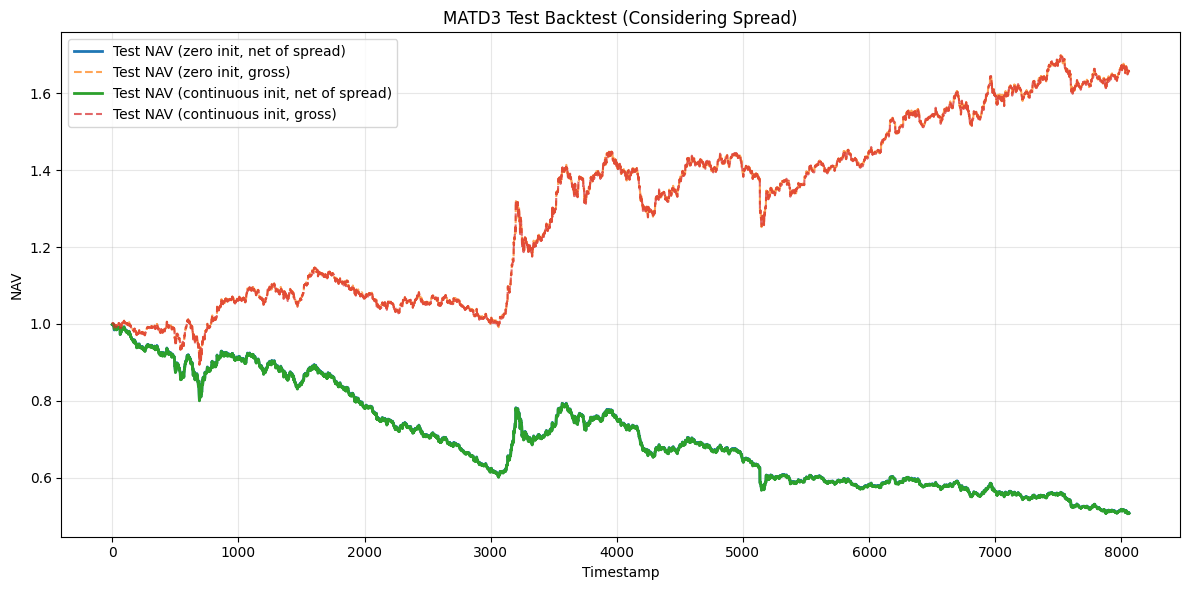

In [40]:
plot_test_backtest_with_spread(
    nav_test_zero=res["nav_test_zero"],
    nav_test_cont=res["nav_test_cont"],
    cfg=cfg,
    title="MATD3 Test Backtest (Considering Spread)",
)